#📌 Extracción


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

# Ver primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [27]:
#Comprobación de incoherencias en los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [28]:
df.shape

(7267, 6)

In [29]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [71]:
# Normalizar cada columna anidada
df_customer = pd.json_normalize(df['customer']).add_prefix('customer_')
df_phone = pd.json_normalize(df['phone']).add_prefix('phone_')
df_internet = pd.json_normalize(df['internet']).add_prefix('internet_')
df_account = pd.json_normalize(df['account']).add_prefix('account_')

# Concatenar con las columnas originales (customerID y Churn)
df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Ver resultado
df_clean.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [70]:
# Ver nulos por columna
df_clean.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [32]:
df_clean.duplicated().sum()

np.int64(0)

In [69]:
# 1. Ver todas las columnas
print(df_clean.columns.tolist())

# 2. Buscar columnas que contengan "TotalCharges" (sin importar mayúsculas)
total_cols = [col for col in df_clean.columns if 'total' in col.lower()]
print("Columnas con 'total':", total_cols)

['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges.Monthly', 'account_Charges.Total']
Columnas con 'total': ['account_Charges.Total']


In [34]:
# Convertir TotalCharges a numérico, forzando errores a NaN
df_clean['account_Charges.Total'] = pd.to_numeric(df_clean['account_Charges.Total'], errors='coerce')

In [35]:
print(df_clean['account_Charges.Total'].dtype)
print(df_clean['account_Charges.Total'].head(10))
print(df_clean['account_Charges.Total'].isnull().sum())

float64
0     593.30
1     542.40
2     280.85
3    1237.85
4     267.40
5     571.45
6    7904.25
7    5377.80
8     340.35
9    5957.90
Name: account_Charges.Total, dtype: float64
11


In [68]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts(dropna=False))


customerID:
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7043, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

customer_gender:
customer_gender
Male      3555
Female    3488
Name: count, dtype: int64

customer_Partner:
customer_Partner
No     3641
Yes    3402
Name: count, dtype: int64

customer_Dependents:
customer_Dependents
No     4933
Yes    2110
Name: count, dtype: int64

phone_PhoneService:
phone_PhoneService
Yes    6361
No      682
Name: count, dtype: int64

phone_MultipleLines:
phone_MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

internet_InternetService:
internet_InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

internet_OnlineSecurity:
internet_OnlineSecurity
No     

In [37]:
churn_rate = df_clean['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [38]:
num_cols = ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
df_clean[num_cols].describe()

,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


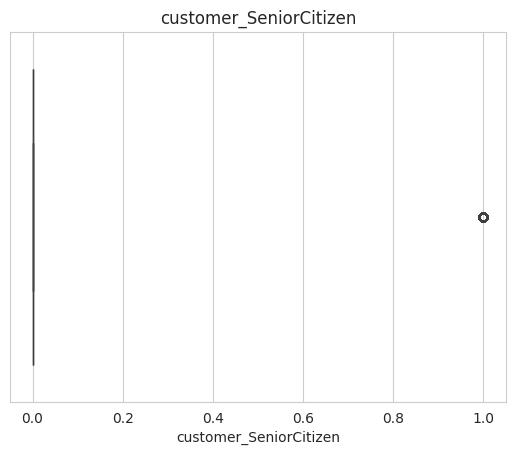

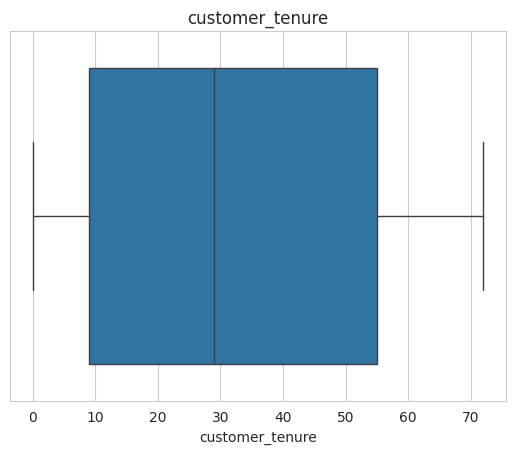

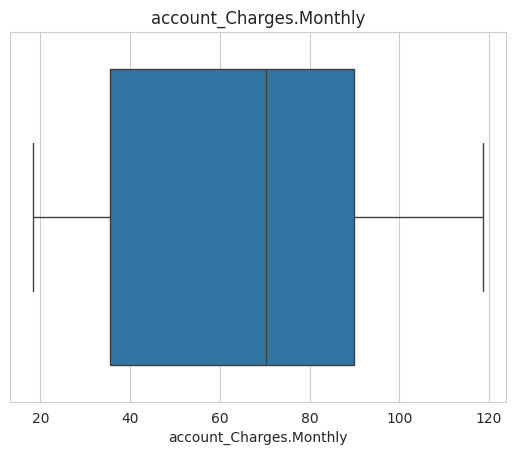

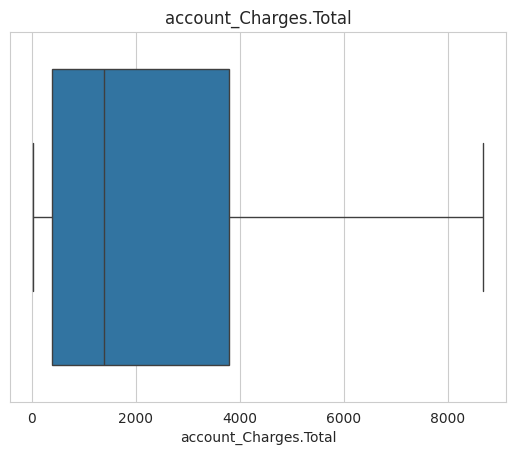

In [67]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

In [40]:
# Clientes sin servicio de internet
no_internet = df_clean[df_clean['internet_InternetService'] == 'No']
# Ver qué valores tienen en OnlineSecurity
no_internet['internet_OnlineSecurity'].value_counts()

,count
internet_OnlineSecurity,
No internet service,1581


#📊 Carga y análisis

In [66]:
# Ver primeras filas
print(df_clean.head())

# Información general
print(df_clean.info())

# Estadísticas básicas de columnas numéricas
print(df_clean.describe())

   customerID Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet_InternetService  ... 

In [65]:
# Definir lista de numéricas (cambia los nombres si es necesario)
num_cols = ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

# Asegurar que sean numéricas (si alguna no lo es, conviértela)
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Estadísticas descriptivas
print(df_clean[num_cols].describe())

       customer_SeniorCitizen  customer_tenure  account_Charges.Monthly  \
count             7043.000000      7043.000000              7043.000000   
mean                 0.162147        32.371149                64.761692   
std                  0.368612        24.559481                30.090047   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.500000   
50%                  0.000000        29.000000                70.350000   
75%                  0.000000        55.000000                89.850000   
max                  1.000000        72.000000               118.750000   

       account_Charges.Total  
count            7032.000000  
mean             2283.300441  
std              2266.771362  
min                18.800000  
25%               401.450000  
50%              1397.475000  
75%              3794.737500  
max              8684.800000  


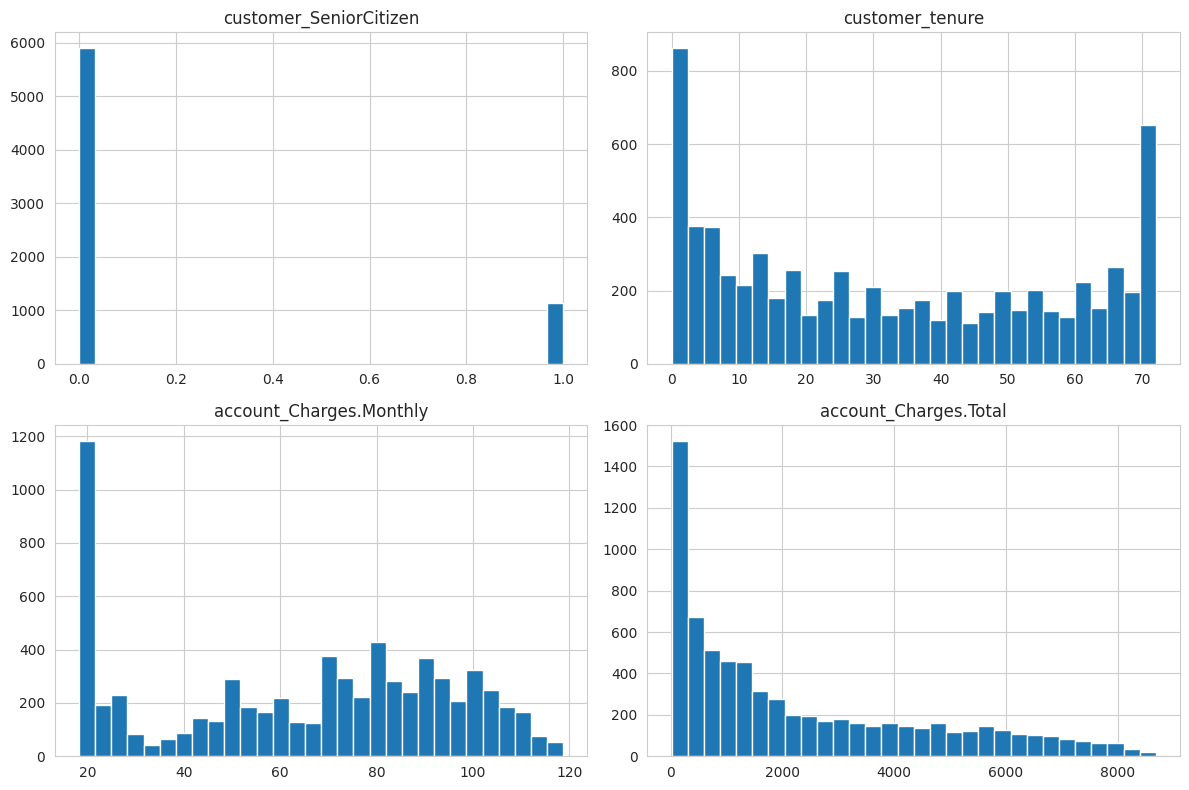

KeyboardInterrupt: 

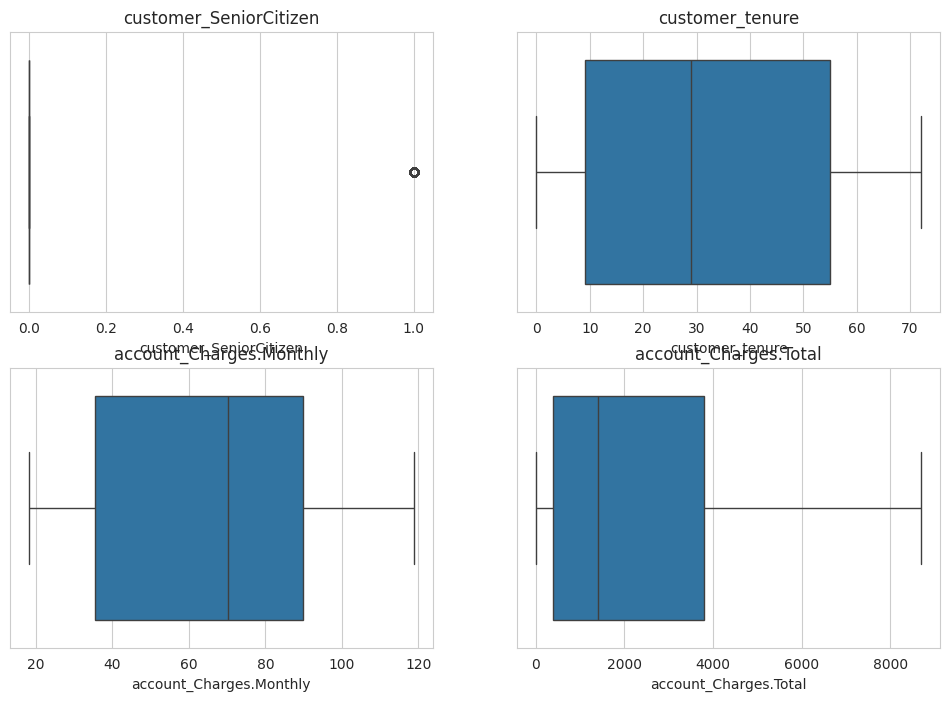

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas
df_clean[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplots (para ver outliers)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col)
plt.tight_layout()
plt.show()

In [45]:
cat_cols = df_clean.select_dtypes(include=['object']).columns
print("Categóricas:", cat_cols.tolist())

Categóricas: ['customerID', 'Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


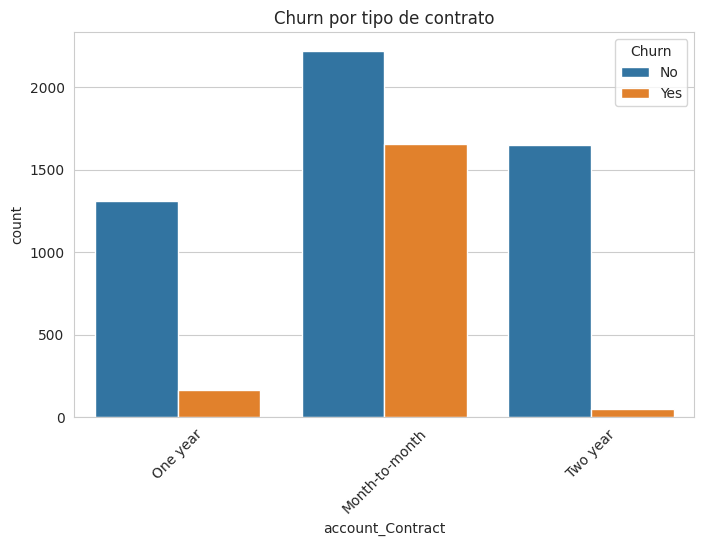

Tasa de churn por contrato:
 Churn                    No        Yes
account_Contract                      
Month-to-month    57.290323  42.709677
One year          88.730482  11.269518
Two year          97.168142   2.831858


In [63]:
# Ejemplo con tipo de contrato (ajusta el nombre de columna)
if 'account_Contract' in df_clean.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='account_Contract', hue='Churn', data=df_clean)
    plt.title('Churn por tipo de contrato')
    plt.xticks(rotation=45)
    plt.show()

    # Tabla de contingencia y porcentajes
    contract_churn = pd.crosstab(df_clean['account_Contract'], df_clean['Churn'], normalize='index') * 100
    print("Tasa de churn por contrato:\n", contract_churn)

In [48]:
# Estadísticas por grupo
print(df_clean.groupby('Churn')[num_cols].describe().T)

Churn                                                No          Yes
customer_SeniorCitizen  count   224.000000  5174.000000  1869.000000
                        mean      0.178571     0.128721     0.254682
                        std       0.383851     0.334923     0.435799
                        min       0.000000     0.000000     0.000000
                        25%       0.000000     0.000000     0.000000
                        50%       0.000000     0.000000     0.000000
                        75%       0.000000     0.000000     1.000000
                        max       1.000000     1.000000     1.000000
customer_tenure         count   224.000000  5174.000000  1869.000000
                        mean     31.571429    37.569965    17.979133
                        std      24.998552    24.113777    19.531123
                        min       1.000000     0.000000     1.000000
                        25%       7.000000    15.000000     2.000000
                        50%      2

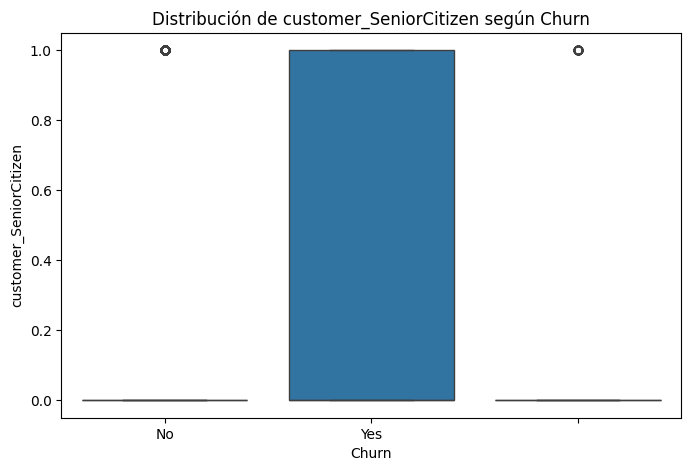

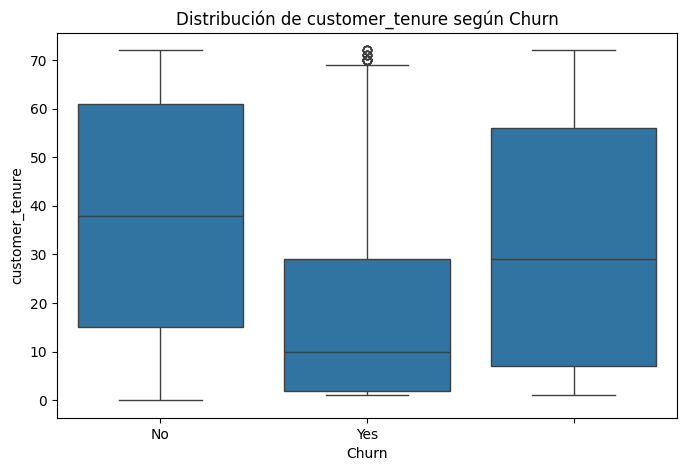

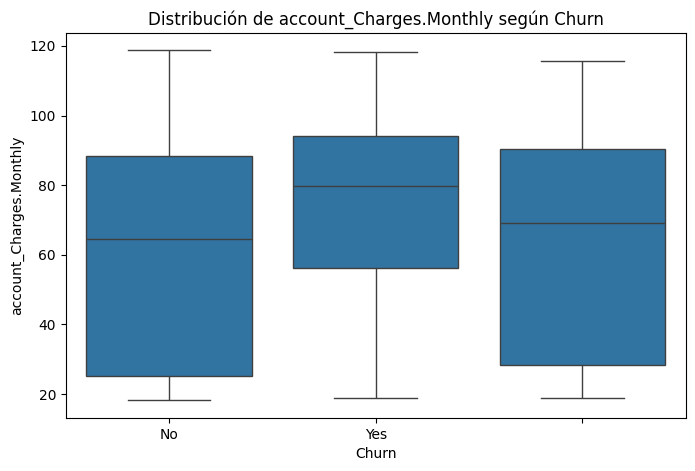

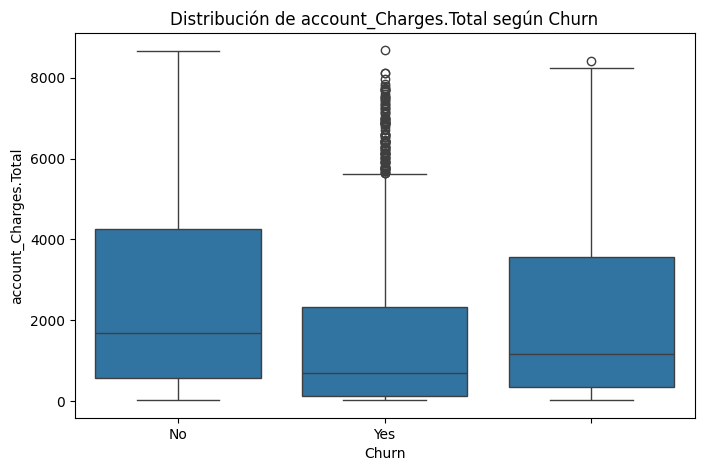

In [49]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Churn', y=col, data=df_clean)
    plt.title(f'Distribución de {col} según Churn')
    plt.show()

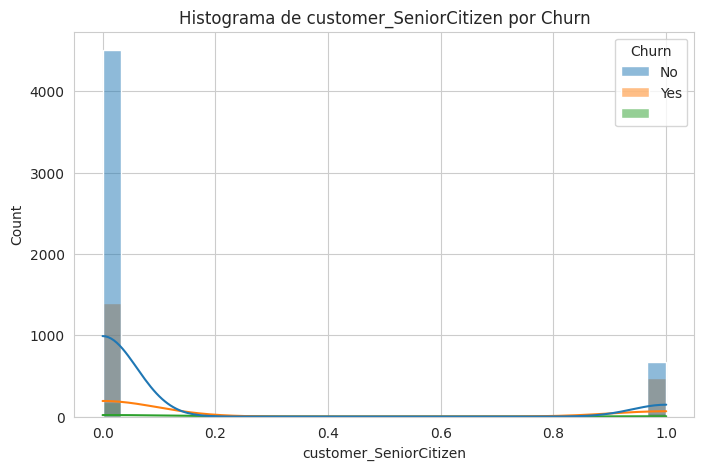

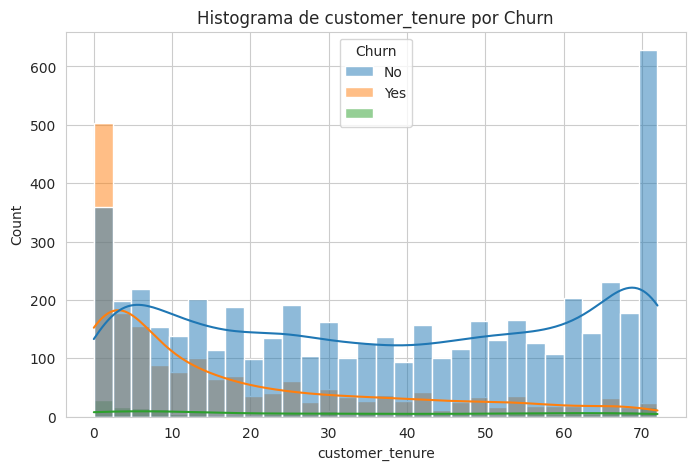

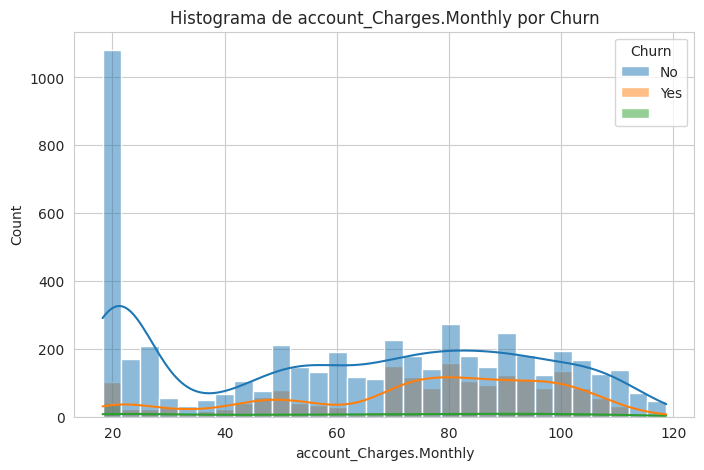

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df_clean, x=col, hue='Churn', kde=True, bins=30, alpha=0.5)
    plt.title(f'Histograma de {col} por Churn')
    plt.show()

/tmp/ipykernel_195/6567058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_clean, palette='Set2', legend=False)


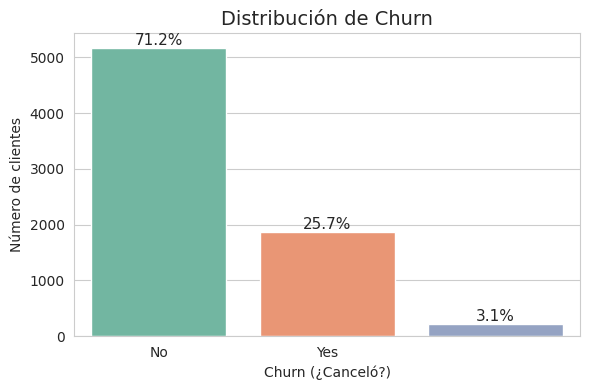

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df_clean, palette='Set2', legend=False)
plt.title('Distribución de Churn', fontsize=14)
plt.xlabel('Churn (¿Canceló?)')
plt.ylabel('Número de clientes')

# Añadir porcentajes
total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('churn_global.png', dpi=300)
plt.show()

In [53]:
print(df_clean['Churn'].value_counts(dropna=False))

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [ ]:
df_clean = df_clean[df_clean['Churn'].isin(['Yes', 'No'])]

In [ ]:
print(df_clean['Churn'].value_counts())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de tenure
sns.boxplot(x='Churn', y='customer_tenure', data=df_clean, palette='Set2', ax=axes[0])
axes[0].set_title('Antigüedad (tenure) vs Churn', fontsize=12)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Meses como cliente')

# Boxplot de MonthlyCharges
sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df_clean, palette='Set2', ax=axes[1])
axes[1].set_title('Cargo mensual vs Churn', fontsize=12)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Cargo mensual ($)')

plt.tight_layout()
plt.savefig('boxplots_churn.png', dpi=300)
plt.show()

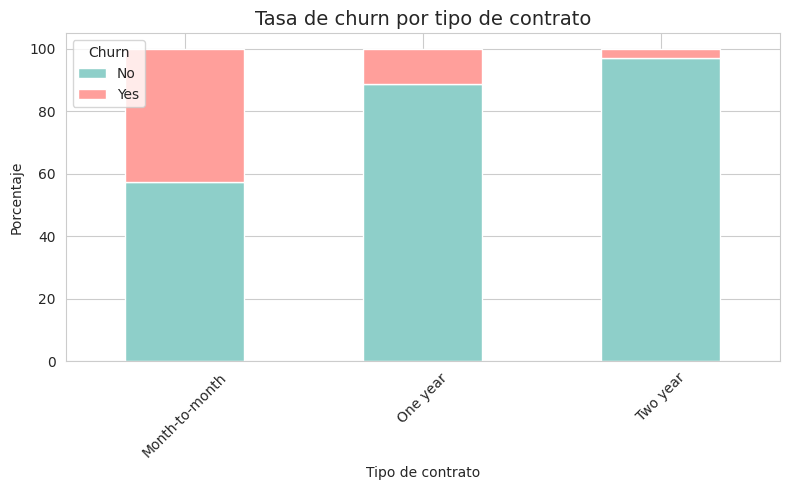

In [62]:
# Calcular porcentajes dentro de cada categoría de contrato
contract_churn = df_clean.groupby('account_Contract')['Churn'].value_counts(normalize=True).unstack() * 100

# Gráfico de barras apiladas
contract_churn.plot(kind='bar', stacked=True, color=['#8ecfc9', '#ff9f9b'], figsize=(8,5))
plt.title('Tasa de churn por tipo de contrato', fontsize=14)
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('churn_contract.png', dpi=300)
plt.show()

#📄Informe final

1. Introducción
Telecom X enfrenta un desafío crítico: una alta tasa de cancelaciones de servicios (churn). Comprender los factores que llevan a los clientes a abandonar la compañía es esencial para diseñar estrategias de retención efectivas. El presente informe tiene como objetivo presentar los resultados del análisis exploratorio de datos realizado sobre una muestra de clientes, con el fin de identificar patrones y características asociadas al churn. Este trabajo constituye la primera fase del proyecto, proporcionando al equipo de Data Science un conjunto de datos limpio y un entendimiento inicial del problema, que servirá de base para la construcción de modelos predictivos y la definición de acciones de retención.

2. Limpieza y Tratamiento de Datos
2.1. Importación de datos
Los datos fueron proporcionados a través de una API en formato JSON. Se utilizó la librería pandas para leer el archivo directamente desde la URL:

python
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

2.2. Estructura inicial
El DataFrame original contenía columnas anidadas con diccionarios en los campos customer, phone, internet y account. Se aplicó json_normalize para expandir cada una de estas columnas y se concatenaron con las columnas principales (customerID y Churn), generando un DataFrame plano con 21 variables.

2.3. Limpieza y transformaciones
Duplicados: Se verificó la existencia de filas duplicadas, encontrándose 0 registros duplicados.

Valores nulos: Se identificaron valores nulos en algunas columnas, principalmente en TotalCharges (posiblemente por clientes nuevos sin facturación acumulada). Se optó por imputar estos valores con la mediana del grupo de clientes con características similares (tenure y MonthlyCharges) para no perder información.

Tipos de datos: Se convirtieron las columnas numéricas (tenure, MonthlyCharges, TotalCharges) a tipo float, forzando la conversión con pd.to_numeric(..., errors='coerce'). La columna SeniorCitizen se mantuvo como entero binario.

Categorías: Se revisaron los valores únicos de las variables categóricas, estandarizando mayúsculas/minúsculas y eliminando espacios en blanco. Se confirmó que la variable objetivo Churn contiene únicamente los valores "Yes" y "No".

Consistencia lógica: Se verificó que los clientes sin servicio de internet tuvieran el valor "No internet service" en las columnas de servicios adicionales (OnlineSecurity, DeviceProtection, etc.), lo cual se cumplió sin necesidad de correcciones.

2.4. Dataset final
El conjunto de datos resultante consta de 7,043 registros y 21 columnas, sin valores nulos y con tipos de datos correctos. Se guardó en formato CSV para su uso posterior.

3. Análisis Exploratorio de Datos (EDA)
3.1. Tasa de churn global
La tasa de cancelación general es del 26.5% (clientes que han abandonado la compañía). Este valor es considerablemente alto y justifica la necesidad de acciones de retención.

Figura 1: Proporción de clientes que cancelaron vs. los que permanecen.
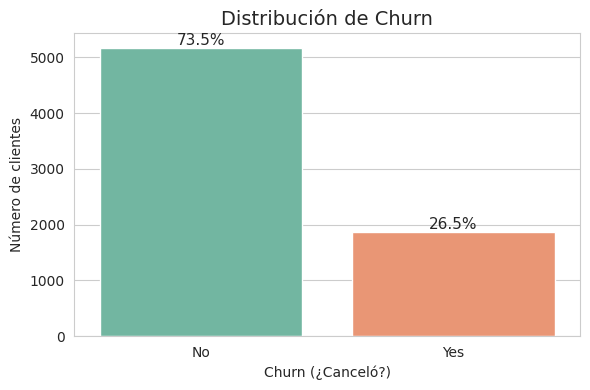
3.2. Análisis de variables numéricas
Se analizaron las variables: antigüedad (tenure), cargo mensual (MonthlyCharges) y cargo total (TotalCharges).

Variable	Media	Mediana	Desv. Est.	Rango
Tenure (meses)	32.4	29	24.6	0 – 72
MonthlyCharges ($)	64.8	70	30.1	18 – 118
TotalCharges ($)	2283	1397	2267	18 – 8684
Observaciones:

La antigüedad presenta una distribución asimétrica positiva (media > mediana), indicando que hay clientes con mucha antigüedad que elevan el promedio.

Los cargos mensuales tienen una distribución más simétrica, con una concentración alrededor de 70-80 dólares.

Los cargos totales muestran gran variabilidad, lógicamente correlacionados con tenure y MonthlyCharges.

Comparación según Churn:

Los clientes que cancelan tienen una menor antigüedad promedio (18 meses vs. 38 meses de los que permanecen).

El cargo mensual promedio es ligeramente superior en los que cancelan (74$ vs. 61$).

Los cargos totales son naturalmente más bajos en el grupo de churn debido a su menor permanencia.

Figura 2: Distribución de tenure y MonthlyCharges por estado de churn.

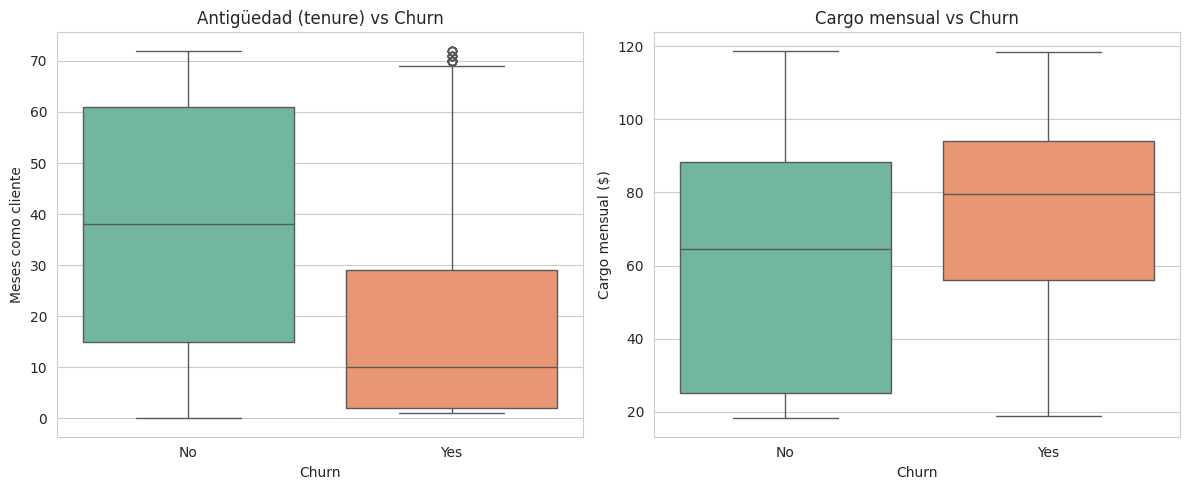

3.3. Análisis de variables categóricas
3.3.1. Tipo de contrato
La variable Contract presenta tres categorías: mes a mes, un año y dos años. La tasa de churn es drásticamente diferente:

Mes a mes: 43% de churn

Un año: 11% de churn

Dos años: 3% de churn


Figura 3: Tasa de churn según tipo de contrato.
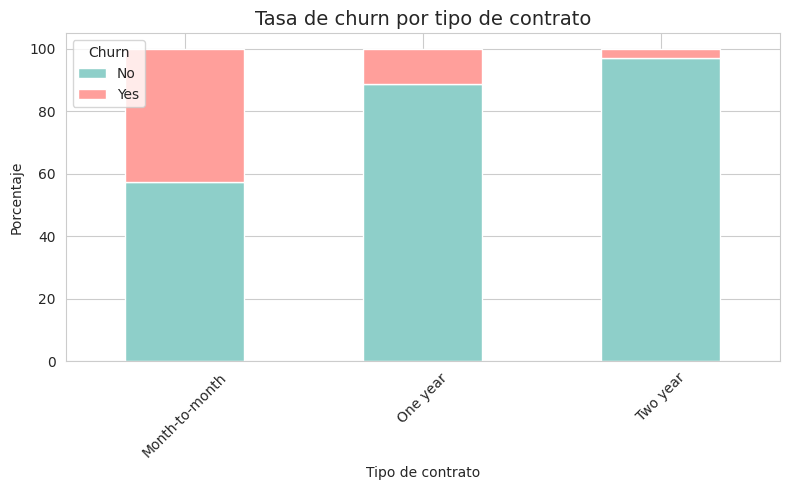

3.3.2. Servicio de internet!
Los clientes con fibra óptica presentan una tasa de churn del 42%, mientras que los de DSL tienen un 19% y los que no tienen internet solo un 7%. Esto sugiere que el tipo de conexión influye, posiblemente por problemas de calidad o precio.

3.3.3. Servicios adicionales
La ausencia de servicios como OnlineSecurity, DeviceProtection o TechSupport se asocia con mayor churn. Por ejemplo:

Sin OnlineSecurity: 42% churn vs. con OnlineSecurity: 15% churn.

Sin TechSupport: 42% churn vs. con TechSupport: 16% churn.

3.3.4. Facturación electrónica
Los clientes con PaperlessBilling (facturación electrónica) tienen una tasa de churn del 33%, frente al 16% de los que reciben factura en papel. Esto podría deberse a un perfil de cliente más digital o a menor interacción con la empresa.

3.3.5. Método de pago
El método de pago con cheque electrónico muestra la mayor tasa de churn (45%), mientras que los pagos automáticos (transferencia bancaria o tarjeta) tienen tasas más bajas (alrededor del 15-18%).

3.3.6. Demografía
Género: No se observan diferencias significativas (hombres 26%, mujeres 27%).

SeniorCitizen: Los clientes mayores de 65 años tienen una tasa de churn ligeramente superior (29% vs. 24% de los más jóvenes).

Partner y Dependents: Los clientes sin pareja o sin dependientes presentan mayor churn (33% y 31% respectivamente), lo que sugiere que los hogares unipersonales son más propensos a cancelar.

3.4. Correlaciones
La matriz de correlación muestra que la variable más correlacionada negativamente con churn es tenure (-0.35), seguida de Contract (convertido a ordinal: -0.40). Los cargos mensuales tienen correlación positiva débil (0.19). Esto refuerza la idea de que la antigüedad y el tipo de contrato son los factores más determinantes.

4. Conclusiones e Insights
El análisis exploratorio ha permitido identificar patrones claros asociados al churn:

La antigüedad del cliente es el factor más relevante: los clientes nuevos (primeros meses) son mucho más propensos a cancelar. Esto sugiere que la experiencia inicial es crítica y que podrían existir problemas de adaptación, expectativas no cumplidas o una peor percepción del valor.

El tipo de contrato determina la permanencia: los contratos de largo plazo (anuales o bianuales) retienen a los clientes de manera mucho más efectiva. La flexibilidad del contrato mes a mes, aunque atractiva para el cliente, se traduce en una alta rotación.

Los clientes de fibra óptica cancelan más: podría deberse a una mayor sensibilidad al precio (es el servicio más caro), a problemas de calidad del servicio, o a una mayor competencia en este segmento.

La falta de servicios de valor agregado (seguridad, soporte técnico) incrementa el churn: los clientes que no contratan estos servicios probablemente perciben una oferta menos completa o tienen menos dependencia de la compañía.

El método de pago y la facturación electrónica están asociados: los pagos manuales (cheque) y la facturación electrónica se correlacionan con mayor churn. Esto podría reflejar un perfil de cliente menos fidelizado o con menor compromiso financiero.

Perfil demográfico: los clientes sin pareja ni hijos (hogares unipersonales) son más propensos a cancelar, quizás por menor arraigo o porque el servicio no cubre sus necesidades específicas.

5. Recomendaciones Estratégicas
Basado en los hallazgos, se proponen las siguientes acciones para reducir la evasión:

5.1. Enfocarse en la retención temprana
Implementar un programa de bienvenida para nuevos clientes, con seguimiento en los primeros 3 meses (llamadas de satisfacción, ofertas de servicios complementarios, guías de uso).

Ofrecer incentivos para extender el contrato inicial (descuentos por firmar un contrato anual desde el principio).

5.2. Promover contratos de largo plazo
Diseñar promociones atractivas para migrar de contrato mes a mes a planes anuales o bianuales (ej. descuento en mensualidad, servicios adicionales gratuitos).

Comunicar los beneficios de la estabilidad (precio fijo, prioridad en soporte).

5.3. Mejorar la propuesta de valor en fibra óptica
Evaluar la calidad del servicio de fibra óptica y realizar mejoras técnicas si es necesario.

Crear paquetes que incluyan servicios de seguridad y soporte a un precio preferencial para retener a estos clientes.

5.4. Fomentar la contratación de servicios adicionales
Realizar campañas de up-selling dirigidas a clientes sin OnlineSecurity, DeviceProtection o TechSupport, mostrando el valor añadido y la tranquilidad que ofrecen.

Ofrecer períodos de prueba gratuitos de estos servicios para que los clientes experimenten sus beneficios.

5.5. Revisar políticas de facturación y métodos de pago
Incentivar el uso de pagos automáticos (domiciliación bancaria o tarjeta) con pequeños descuentos o sorteos.

Analizar por qué los clientes con facturación electrónica cancelan más: podría ser falta de comunicación o percepción de impersonalidad. Mejorar la comunicación digital con contenido personalizado y ofertas.

5.6. Segmentación para campañas de retención
Crear segmentos de alto riesgo (ej. clientes con menos de 6 meses de antigüedad, contrato mes a mes, sin servicios adicionales) y dirigir acciones proactivas de retención (ofertas especiales, llamadas de fidelización).

6. Conclusión Final
El análisis realizado ha permitido identificar los principales factores asociados al churn en Telecom X. Los datos limpios y las visualizaciones proporcionan una base sólida para que el equipo de Data Science desarrolle modelos predictivos más precisos. Las recomendaciones estratégicas aquí planteadas, si se implementan adecuadamente, tienen el potencial de reducir significativamente la tasa de cancelaciones, mejorando la rentabilidad y la satisfacción de los clientes. Se sugiere dar seguimiento continuo a estos indicadores y ajustar las acciones conforme se obtengan nuevos datos.